# Virtual Screening with AutoDock Vina

In this exercise, we will dock a virtual library of compounds into the binding site of MOR.

So far this semester, we have used high-performance computing resources **interactively**. For most of the exercises, we started a job to run a JupyterLab instance. We have also started an interactive job to install JupyterLab. Interactive jobs are meant to run for a short time while you are using the computer. These are most suitable for calculations that do not take very long.

In this exercise and in some future exercises, we will use high-performance computing resources via **batch** jobs, which are meant for longer calculations. Once a batch job is submitted, you do **not** need to keep the browser open for the calculations to continue running.


Assuming that you are reading this Notebook on Github, you will need to download it to your account on SDSC Expanse. To do that, log onto the Expanse User Portal, select *Shell*, and paste the following commands into the terminal:

```bash
mkdir -p ~/exercises
cd ~/exercises
curl -L -o 06-Virtual_Screening.ipynb https://raw.githubusercontent.com/daveminh/Chem456-2026S/refs/heads/main/exercises/06-Virtual_Screening.ipynb
```

You should also download a virtual library of FDA-approved drugs and metabolites from [e-Drug3D](https://chemoinfo.ipmc.cnrs.fr/MOLDB/index.php). Scroll down to `Download the current version of the e-Drug3D collection (sdf format file)` and copy the link to the database file. Use the link to replace the word LINK in the code below:
```bash
mkdir -p ~/exercises/06
cd ~/exercises/06
curl -L -o e-Drug3D.sdf LINK
```

To start JupyterLab, you can paste the following commands into the shell. You can adjust the time limit, but 1.5 hours is good to run for the class period and does not use too many computing resources in case you forget to shut down.

```bash
/cm/shared/apps/sdsc/galyleo/galyleo launch --account iit130 --partition shared --cpus 4 --memory 8 --time-limit 01:30:00 --interface lab --conda-env visualization --conda-init "$HOME/miniconda3/etc/profile.d/conda.sh"
```

After you start JupyterLab, navigate to the notebook.

The exercise will be graded based on submitting your answers to the questions after ```-->``` on Canvas.

# Part 0 - Importing the Required Software

In Exercise 5, we installed AutoDock Vina and associated tools. If you did not do this, go back to Exercise 5 to see instructions. The code snippet below will initate this notebook to run these packages.

In [ ]:
import os
from pathlib import Path
import sys, platform
from prody import *
from rdkit import Chem
from rdkit.Chem import AllChem
import rdkit, nglview
print("rdkit version:", rdkit.__version__)
print("nglview version:", nglview.__version__)
from ipywidgets import interact, IntSlider
import ipywidgets, copy
from IPython.display import display, Markdown

import os
scrub_path = !which scrub.py
bin_path = Path(os.path.dirname(scrub_path[0])[:-3] + "bin")
env_path = Path(os.path.dirname(scrub_path[0])[:-3])

# Helper function
def locate_file(from_path = None, query_path = None, query_name = "query file"):
    if not from_path or not query_path:
        raise ValueError("Must specify from_path and query_path")

    possible_path = list(from_path.glob(query_path))

    if not possible_path:
        raise FileNotFoundError(f"Cannot find {query_name} from {from_path} by {query_path}")

    return_which = (
        f"using {query_name} at:\n"
        f"{possible_path[0]}\n"
    )
    print(return_which)

    return possible_path[0]

# Commandline scripts
scrub = locate_file(from_path = bin_path, query_path = "scrub.py", query_name = "scrub.py")
mk_prepare_ligand = locate_file(from_path = bin_path, query_path = "mk_prepare_ligand.py", query_name = "mk_prepare_ligand.py")
mk_prepare_receptor = locate_file(from_path = bin_path, query_path = "mk_prepare_receptor.py", query_name = "mk_prepare_receptor.py")
mk_export = locate_file(from_path = bin_path, query_path = "mk_export.py", query_name = "mk_export.py")

# Part 1 – Preparing the Ligand Library for AutoDock

In contrast to Exercise 5, where we docked a **single** ligand to MOR, we will dock a **library** of ligands to MOR. 

As an example, we will dock all FDA approved drugs. Unless the protein requires an important conformational change for drug binding, we would expect MOR-targeting drugs to have low docking scores. You may want to dock these drugs to your own targets to see whether they could be repurposed or could be a lead for your target. Approved drugs could be attractive drug leads because they have already demonstrated a reasonable level of safety.

At the beginning of the exercise, you should have downloaded the databased from [e‑Drug3D](https://chemoinfo.ipmc.cnrs.fr/MOLDB/index.php). Make sure that the file `~/exercises/06/e-Drug3D.sdf` exists. Then run scrub to prepare various protonation and tautomeric states.

In [ ]:
pH = 6 #@param {type:"raw"}

# @markdown > The following two options allow you to opt out from enumeration of tautomers or protomers.
skip_tautomer = False #@param {type:"boolean"}
skip_acidbase = False #@param {type:"boolean"}

args = ""
if skip_tautomer:
  args += "--skip_tautomer "
if skip_acidbase:
  args += "--skip_acidbase "

! python {scrub} 06/e-Drug3D.sdf -o 06/e-Drug3D_scrubbed.sdf --ph {pH} {args}

## --> How many molecules were the e-Drug3D file? How many were prepared for AutoDock? How many total tautomers and acid/based conjugates were identified?

## --> Why should tautomers be treated as different molecules in AutoDock?

Now use [Meeko](https://meeko.readthedocs.io/en/develop/index.html) to generate ligand pdbqt files, the input into AutoDock Vina. Meeko adds an extra space to the names of several drugs, so I wrote some python code to remove these. 

In [ ]:
# Convert conformers to ligand PDBQT files
! mkdir -p 06/FDA
! python {mk_prepare_ligand} -i 06/e-Drug3D_scrubbed.sdf --multimol_outdir 06/FDA/ --name_from_prop name

import glob, shutil
FNs = glob.glob('06/FDA/*')
for FN in FNs:
    if FN.find(' ')>-1:
        FN_n = FN.replace(' ','')
        print(f'Renaming {FN} to {FN_n}')
        shutil.move(FN, FN_n)

You can see all the pdbqt files in the `~/exercises/06/FDA folder`. The code below will visualize ligands within the list. You can show or hide a representation using the GUI.

In [ ]:
ligands = ["NIRMATRELVIR"]
for ligand in ligands:
    ! python {mk_export} 06/FDA/{ligand}.pdbqt -s 06/FDA/{ligand}.sdf

# Visualization with nglview
import nglview as nv
view = nv.NGLWidget()
for ligand in ligands:
    view.add_component(f"06/FDA/{ligand}.sdf")
view.display(gui=True)

Instead of docking all FDA approved drugs, we will pick an random subset to save compute time.

In [ ]:
! mkdir -p 06/chemical_library

import glob, shutil
FNs = glob.glob('06/FDA/*')
import numpy as np
for FN in np.random.permutation(FNs)[:100]:
    shutil.copy2(FN, os.path.join('06','chemical_library',os.path.basename(FN)))

# Part 2 – Performing Virtual Screening with AutoDock Vina

In Exercise 5, we prepared the receptor in Exercise 5. If you did not do this, go back to Exercise 5 to see instructions. 

Now, we will generate a configuration file for **Autodock**. The configuration file is similar to Exercise 5, but we omit a ligand file.

In [ ]:
box_center = [0, 16, 7]
box_size = [12, 12, 15]

with open("06/vina_config.txt","w") as f:
    f.write(f"""#CONFIGURATION FILE (options not used are commented)
#INPUT OPTIONS
receptor = ../05/receptor.pdbqt
#flex = [flexible residues in receptor in pdbqt format]
#SEARCH SPACE CONFIGURATIONS
#Center of the box (values cx, cy and cz)
center_x = {box_center[0]}
center_y = {box_center[1]}
center_z = {box_center[2]}
#Size of the box (values szx, szy and szz)
size_x = {box_size[0]}
size_y = {box_size[1]}
size_z = {box_size[2]}
#MORE OPTIONS
#OUTPUT OPTIONS
#out =
#log =

#OTHER OPTIONS
cpu = 4
exhaustiveness = 8
#num_modes =
#energy_range =
#seed = """)

Now, we will create and submit a job script. If you define the `email_address` variable, you will receive an email when your job state changes (start, end, fail). In the job script, the first line says that the script should be run in the bash shell, which we learned at the beginning of the semester and have been using within Jupyter Notebooks. The lines that start with `#SBATCH` are options for the sbatch command from the [Slurm workload manager](https://slurm.schedmd.com/quickstart.html). The remaining lines could be entered into a command terminal. For more details, see the documentation on [submitting jobs on Expanse](https://www.sdsc.edu/systems/expanse/user_guide.html#narrow-wysiwyg-7). The last part of the snippet submits the job.

In [ ]:
email_address = ''
if email_address != '':
    email_lines = f"""#SBATCH --mail-user={email_address}
#SBATCH --mail-type=ALL"""

with open("06/vina.job","w") as f:
    f.write(f"""#!/bin/bash
#SBATCH --account=iit130
#SBATCH --partition=shared
#SBATCH --nodes=1
#SBATCH --ntasks-per-node=4
#SBATCH --mem=10G
#SBATCH --time=24:00:00
#SBATCH --job-name="vina"
#SBATCH --output="vina.%j.%N.out"
#SBATCH --export=ALL
{email_lines}

cd ~/exercises/06
mkdir -p poses
vina --config vina_config.txt --batch chemical_library/*.pdbqt --dir poses
""")

%cd 06
! sbatch vina.job
%cd ..

After running the cell above, go to Expanse Portal -> Active Jobs. Click the `>` by the vina job.

## --> What is the `Job Id` and `Node List`?

Now you wait. You can shut down the JupyterLab session. After your job is complete, you can start a new JupyterLab sesion and move on to Part 3.

In [ ]:
# Moves pdbqt files of complete jobs to the poses directory
import os, glob, shutil
FNs_done = glob.glob('06/poses/*out.pdbqt')
for FN in FNs_done:
    basename = os.path.basename(FN).replace('_out','')
    FN_o = os.path.join('06','chemical_library',basename)
    if os.path.isfile(FN_o):
        shutil.move(FN_o, os.path.join('06','poses',basename))

# Part 3 - Analysis of Virtual Screening

In [ ]:
# Read docking scores into an array
FNs_done = sorted(glob.glob('06/poses/*out.pdbqt'))
scores = []
for FN in FNs_done:
    F = open(FN,'r')
    F.readline()
    scores.append(float(F.readline()[23:30]))

import numpy as np

drugs = [os.path.basename(FN)[:-10] for FN in FNs_done]
scores = np.array(scores)

print(f'Number of docking scores: {len(scores)}')
print(f'Number of negative docking scores: {sum(scores<0)}')

In [ ]:
# Create a histogram of docking scores
import matplotlib.pyplot as plt

plt.figure()
plt.hist(scores[scores<0])
plt.gca().set(title='Histogram of negative docking scores', xlabel='Score (kcal/mol)', ylabel='Frequency');

In [ ]:
# Prints a list of drugs and scores in ascending order
print('\n'.join([f"{drug:30s}\t{score}" for score, drug in sorted(zip(scores, drugs))]))

## --> What are the names and docking scores of your top 10 drugs? Do any drugs appear twice? Are any known to target MOR? See https://ttd.idrblab.cn/data/target/details/T47768.

The following cell visualizes different docking poses of `drug` in the receptor binding site.

In [ ]:
drug = "BITOLTEROL-again7"

# Convert AutoDock Vina output into a SDF file
! python {mk_export} 06/poses/{drug}_out.pdbqt -s 06/poses/{drug}_out.sdf

import prody
receptor_prody = prody.parsePDB('04/8ef6_OPM.pdb')

from rdkit import Chem
import nglview as nv
import ipywidgets as widgets

view = nv.NGLWidget()
view.add_component(receptor_prody.select('protein and chain R'))
view.add_component(receptor_prody.select('(same residue as within 5 of resname MOI) and protein and chain R'))
view[1].clear_representations()
view[1].add_representation("surface", opacity=0.5)
view[1].add_representation("licorice", opacity=0.5)

poses = []
suppl = Chem.SDMolSupplier(f"06/poses/{drug}_out.sdf")
for mol in suppl:
    if mol is not None:
        poses.append(view.add_component(mol))
view.display(gui=True)

mode_idx = widgets.IntSlider(value=1, min=1, max=len(poses), readout=True, readout_format='d', description='Mode')

def update_pose(mode_idx):
    for pose in poses:
        pose.hide()
    poses[mode_idx-1].show()
    view.display()

view_container = widgets.Box([view])
out = widgets.interactive_output(update_pose, {'mode_idx': mode_idx})
ui = widgets.VBox([view_container, mode_idx])
display(ui)

## --> What ligand has the lowest predicted binding free energy and what is its predicted binding pose? Take a screenshot and post it in your assignment on Canvas.

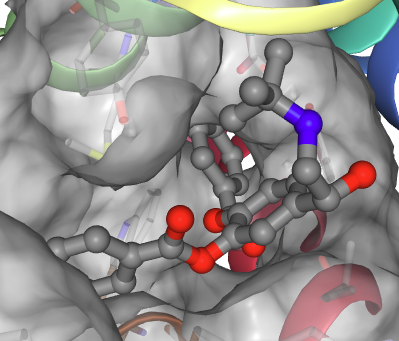

**And this is the end of the virtual screening tutorial!**